In [1]:
# import openkarst
import pykasso as pk
import importlib
importlib.reload(pk)
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx
import openkarst.models
importlib.reload(openkarst.models)
import openkarst.io.cave_data_loader as cdl
importlib.reload(cdl)
import seaborn as sns
import openpnm as op
import contextily as cx
import geopandas as gpd
import pyarrow
import pickle
import json
import pwlf
import re
from openkarst.network_generation import compute_conduit_lengths
from openkarst.visualization.animation_pyvista import animate_network
from openkarst.models import FlowSimulation
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../src"))) #use this to be able to import local packages


In [54]:
import utils.config as config
importlib.reload(config)
import utils.common as common
importlib.reload(common)
import utils.conduits as conduits
importlib.reload(conduits)
from utils.common import *
from utils.config import * 
from utils.calibration import *
from utils.conduits import *
from utils.geos import *
import scripts.openkarst.run_openkarst as ok
import utils.openkarst_network
importlib.reload(utils.openkarst_network)
importlib.reload(ok)
import utils.linear_reservoir as lr
importlib.reload(lr)
import utils.spring as spring
importlib.reload(spring)
from utils.spring import outlet_flow, write_outlet_flow, calculate_recession_coefficients
from scripts.openkarst.run_openkarst import load_network_data

In [34]:
metadata = pd.read_parquet('conduit_geometry_test/output/metadata').reset_index(drop=True)
Q = {}
def sanitize_run_id(run_id):
    return re.sub(r"[^0-9A-Za-z_-]", "_", str(run_id))

for index, row in metadata.iterrows():
    run_id_raw = row['run_id']
    run_id = sanitize_run_id(run_id_raw)
    print(run_id)
    output_dir = f'conduit_geometry_test/{row["output_dir"]}'
    network_name = row["network_name"]
    if network_name == 'anastomotic_simple':
        continue
    if network_name == 'pykasso_n58_low_slope':
        network_dir = 'conduit_geometry_test/networks/pykasso_n58/low_slope'
    else:
        network_dir = f'conduit_geometry_test/networks/{network_name}'
    network = load_network_data(f'{network_dir}/nodes.csv', f'{network_dir}/edges.csv')
    results = np.load(f'{output_dir}/results_arrays.npz')
    Q = results['Q']
    y = results['y']
    t = results['t']
    spring = outlet_flow(network, Q)
    write_outlet_flow(t, spring,f'conduit_geometry_test/output/hydrographs_df', run_id = run_id, method = 'dataframe')
    print(index)


2026-05-07_00_45_24_1_0
2026-05-07_00_45_24_2_0
1
2026-05-07_00_45_24_3_0
2
2026-05-07_00_45_24_4_0
3
2026-05-07_00_45_24_6_0
4
2026-05-07_12_00_24_1_0
2026-05-07_12_00_24_2_0
6
2026-05-07_12_00_24_3_0
7
2026-05-07_12_00_24_4_0
8
2026-05-07_12_00_24_6_0
9
2026-05-07_15_40_23_1_0
10
2026-05-07_15_40_23_2_0
11
2026-05-11_22_13_26_1_0


FileNotFoundError: [Errno 2] No such file or directory: 'conduit_geometry_test/output/anastomotic_low_slope/partitioned/results_arrays.npz'

In [11]:
'anastomotic_simple_low_slope/double_gaussian',
'anastomotic_simple_clean/double_gaussian',
'branching_straight_network/double_gaussian',
'pykasso_n58_low_slope/double_gaussian',
'pykasso_n58/double_gaussian',
'single_conduit_vert_tort/double_gaussian',
'slope_0008/double_gaussian',
'straight_conduit_n62/double_gaussian'

'straight_conduit_n62/double_gaussian'

In [26]:

sim_list =['anastomotic_simple_low_slope',
'anastomotic_simple_clean',
'branching_straight_network',
'pykasso_n58_low_slope',
'pykasso_n58',
'single_conduit_vert_tort',
'slope_0008',
'straight_conduit_n62']
Qs = {}
for network_name in sim_list:
    network_output = f'conduit_geometry_test/output/{network_name}'
    run_dirs = os.listdir(network_output)
    Qs[network_name] = {}
    for run in run_dirs:
        spring_path = f'{network_output}/{run}/spring.csv'
        try: 
            spring_Q = pd.read_csv(spring_path)
            Qs[network_name][run] = spring_Q
        except FileNotFoundError:
            try:
                results = np.load(f'{network_output}/{run}/results_arrays.npz')
            except FileNotFoundError:
                print(f'skipping {network_output}/{run}')
                continue
            input_data = load_pickle( f'{network_output}/{run}/input_data.pkl')
            network =utils.openkarst_network.OpenKarstNetwork(nodes = input_data['nodes'], edges = input_data['edges'])
            network.load_cave_data()
            Q = results['Q']
            y = results['y']
            t = results['t']
            spring_Q = outlet_flow(network, Q)
            Qs[network_name][run] = spring_Q
            continue


skipping conduit_geometry_test/output/anastomotic_simple_low_slope/diffuse
skipping conduit_geometry_test/output/anastomotic_simple_low_slope/double_gaussian
skipping conduit_geometry_test/output/anastomotic_simple_clean/diffuse
skipping conduit_geometry_test/output/anastomotic_simple_clean/double_gaussian
skipping conduit_geometry_test/output/branching_straight_network/double_gaussian
skipping conduit_geometry_test/output/branching_straight_network/low_slope
skipping conduit_geometry_test/output/pykasso_n58_low_slope/double_gaussian
skipping conduit_geometry_test/output/pykasso_n58/double_gaussian
skipping conduit_geometry_test/output/pykasso_n58/low_slope
skipping conduit_geometry_test/output/single_conduit_vert_tort/diffuse
skipping conduit_geometry_test/output/single_conduit_vert_tort/double_gaussian
skipping conduit_geometry_test/output/slope_0008/double_gaussian
skipping conduit_geometry_test/output/straight_conduit_n62/double_gaussian


In [31]:
metadata = pd.read_parquet('conduit_geometry_test/output/metadata').reset_index(drop=True)


In [32]:
metadata

,network_name,recharge_file,recharge_distribution,baseflow,output_dir,run_id
0,anastomotic_simple,input_data/recharge_m_s/gaussian_pulse.csv,partitioned,0.02,output/anastomotic_simple/partitioned,2026-05-07 00:45:24_1_0
1,branching_straight_network,input_data/recharge_m_s/gaussian_pulse.csv,partitioned,0.02,output/branching_straight_network/partitioned,2026-05-07 00:45:24_2_0
2,pykasso_n58_low_slope,input_data/recharge_m_s/gaussian_pulse.csv,partitioned,0.02,output/pykasso_n58_low_slope/partitioned,2026-05-07 00:45:24_3_0
3,pykasso_n58,input_data/recharge_m_s/gaussian_pulse.csv,partitioned,0.02,output/pykasso_n58/partitioned,2026-05-07 00:45:24_4_0
4,straight_conduit_n62,input_data/recharge_m_s/gaussian_pulse.csv,partitioned,0.02,output/straight_conduit_n62/partitioned,2026-05-07 00:45:24_6_0
5,anastomotic_simple,input_data/recharge_m_s/gaussian_pulse.csv,diffuse,0.02,output/anastomotic_simple/diffuse,2026-05-07 12:00:24_1_0
6,branching_straight_network,input_data/recharge_m_s/gaussian_pulse.csv,diffuse,0.02,output/branching_straight_network/diffuse,2026-05-07 12:00:24_2_0
7,pykasso_n58_low_slope,input_data/recharge_m_s/gaussian_pulse.csv,diffuse,0.02,output/pykasso_n58_low_slope/diffuse,2026-05-07 12:00:24_3_0
8,pykasso_n58,input_data/recharge_m_s/gaussian_pulse.csv,diffuse,0.02,output/pykasso_n58/diffuse,2026-05-07 12:00:24_4_0
9,straight_conduit_n62,input_data/recharge_m_s/gaussian_pulse.csv,diffuse,0.02,output/straight_conduit_n62/diffuse,2026-05-07 12:00:24_6_0


In [40]:
all_Q= {}
for run_id in metadata['run_id']:
    
    network_name = metadata.loc[metadata['run_id'] == run_id, 'network_name'].values[0]
    output_dir = metadata.loc[metadata['run_id'] == run_id, 'output_dir'].values[0]
    clean_run_id = sanitize_run_id(run_id)
    recharge = metadata.loc[metadata['run_id'] == run_id, 'recharge_file'].values[0].split('/')[-1].split('.')[0]
    r_dist = metadata.loc[metadata['run_id'] == run_id, 'recharge_distribution'].values[0]
    try:

        all_Q[f'{network_name}_{recharge}_{r_dist}'] = pd.read_csv(f'conduit_geometry_test/output/hydrographs_df/{clean_run_id}.csv')
    except FileNotFoundError:
        try:
            results = np.load(f'conduit_geometry_test/{output_dir}/results_arrays.npz')    
            Q = results['Q']
            y = results['y']
            t = results['t']
            spring = outlet_flow(network, Q)
            write_outlet_flow(t, spring,f'conduit_geometry_test/output/hydrographs_df', run_id = clean_run_id, method = 'dataframe')
        except FileNotFoundError:
            continue

In [41]:
all_Q

{'anastomotic_simple_gaussian_pulse_partitioned':                time  spring         Q                   run_id
 0      1.002453e+02      33  0.036346  2026-05-07_00_45_24_1_0
 1      2.002046e+02      33  0.035284  2026-05-07_00_45_24_1_0
 2      3.001052e+02      33  0.034672  2026-05-07_00_45_24_1_0
 3      4.000223e+02      33  0.034309  2026-05-07_00_45_24_1_0
 4      5.002376e+02      33  0.034079  2026-05-07_00_45_24_1_0
 ...             ...     ...       ...                      ...
 21594  2.159500e+06      33  0.036091  2026-05-07_00_45_24_1_0
 21595  2.159600e+06      33  0.036091  2026-05-07_00_45_24_1_0
 21596  2.159700e+06      33  0.036091  2026-05-07_00_45_24_1_0
 21597  2.159800e+06      33  0.036091  2026-05-07_00_45_24_1_0
 21598  2.159900e+06      33  0.036091  2026-05-07_00_45_24_1_0
 
 [21599 rows x 4 columns],
 'branching_straight_network_gaussian_pulse_partitioned':                time  spring         Q                   run_id
 0      1.002216e+02       6  0.0

In [ ]:
r = pd.read_csv('conduit_geometry_test/input_data/recharge_m_s/gaussian_pulse.csv')


In [194]:
test = all_Q['anastomotic_simple']
t1 = test['time']
Q1 = test['Q']
r_interp = np.interp(t1, r['time'], r['R_l [V/T]'] + r['R_h [V/T]'])

In [48]:
all_Q.keys()

dict_keys(['anastomotic_simple_gaussian_pulse_partitioned', 'branching_straight_network_gaussian_pulse_partitioned', 'pykasso_n58_low_slope_gaussian_pulse_partitioned', 'pykasso_n58_gaussian_pulse_partitioned', 'straight_conduit_n62_gaussian_pulse_partitioned', 'branching_straight_network_gaussian_pulse_diffuse', 'pykasso_n58_low_slope_gaussian_pulse_diffuse', 'pykasso_n58_gaussian_pulse_diffuse', 'straight_conduit_n62_gaussian_pulse_diffuse', 'anastomotic_simple_clean_gaussian_pulse_partitioned', 'single_conduit_vert_tort_gaussian_pulse_partitioned', 'anastomotic_low_slope_gaussian_pulse_partitioned', 'anastomotic_low_slope_double_gaussian_partitioned', 'anastomotic_simple_clean_double_gaussian_partitioned', 'branching_straight_network_double_gaussian_partitioned', 'pykasso_n58_low_slope_double_gaussian_partitioned', 'pykasso_n58_double_gaussian_partitioned', 'single_conduit_vert_tort_double_gaussian_partitioned', 'slope_0008_double_gaussian_partitioned', 'straight_conduit_n62_double_

<Axes: xlabel='time', ylabel='Q'>

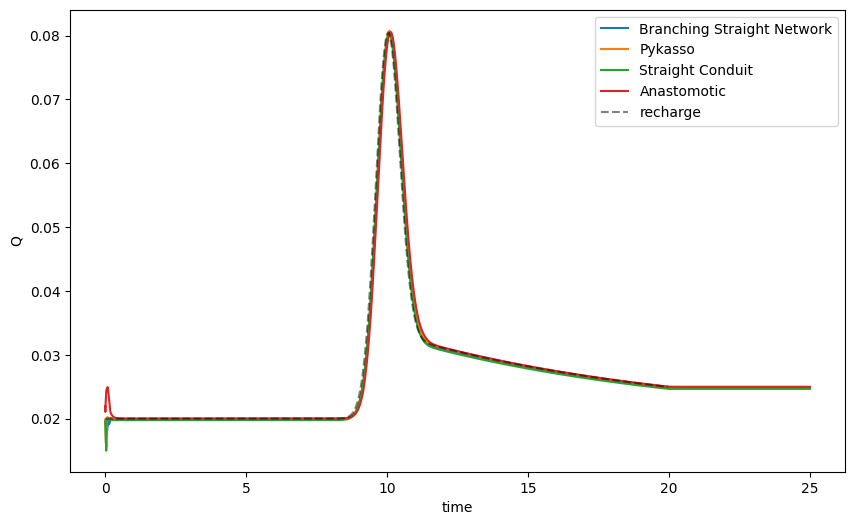

In [83]:
label_dict = {'branching_straight_network_gaussian_pulse_partitioned' : 'Branching Straight Network', 
              'pykasso_n58_low_slope_gaussian_pulse_partitioned' : 'Pykasso Low Slope', 
              'pykasso_n58_gaussian_pulse_partitioned' : 'Pykasso', 
              'straight_conduit_n62_gaussian_pulse_partitioned' : 'Straight Conduit', 
               'anastomotic_simple_clean_gaussian_pulse_partitioned' : 'Anastomotic', 
               'single_conduit_vert_tort_gaussian_pulse_partitioned' : 'Vertically Tortuous', 
               'anastomotic_low_slope_gaussian_pulse_partitioned' : 'Anastomotic Low Slope'
}
conditions = lambda name: ('double_gaussian'in name) or (name in ['anastomotic_simple_gaussian_pulse_partitioned', 'pykasso_n58_low_slope_gaussian_pulse_partitioned']) or ('diffuse' in name) or ('single_conduit_vert_tort' in name) or ('anastomotic_low_slope' in name)
fig, ax = plt.subplots(figsize=(10,6))
for name, Q_spring in all_Q.items():
    if conditions(name):
        continue
    sns.lineplot(x=Q_spring['time']/86400, y=Q_spring['Q'], label=label_dict.get(name, name))
    
sns.lineplot(x=r['time']/86400, y=r['R_l [V/T]'] + r['R_h [V/T]'], label='recharge', color='k', linestyle='--', alpha = 0.5)

In [84]:
analysis_df =pd.DataFrame(columns=['network_name', 'alpha_1', 'alpha_2', 'alpha_3', 't_alpha_1', 't_alpha_2', 't_alpha_3', 'volume'])
for name, Q_spring in all_Q.items():
    if conditions(name):
        continue
    try:
        alpha, t_alpha = calculate_recession_coefficients(Q_spring['time'], Q_spring['Q'], n_coeffs=3)
        alpha *= -1
        volume = spring.calculate_volume(Q_spring['time'], Q_spring['Q'])
        analysis_df.loc[len(analysis_df)] = {'network_name': label_dict[name], 'alpha_1': alpha[0], 'alpha_2': alpha[1], 'alpha_3': alpha[2], 't_alpha_1': t_alpha[0], 't_alpha_2': t_alpha[1], 't_alpha_3': t_alpha[2], 'volume': volume}
    except Exception as e:
        print(f"Error processing {name}: {e}")
        continue

In [85]:
analysis_df

,network_name,alpha_1,alpha_2,alpha_3,t_alpha_1,t_alpha_2,t_alpha_3,volume
0,Branching Straight Network,0.000011,3.427115e-07,1.301285e-08,872000.191561,966278.776048,1.656833e+06,57264.244609
1,Pykasso,0.000011,3.429668e-07,1.262953e-08,871200.255011,964975.335387,1.656090e+06,57601.780594
2,Straight Conduit,0.000011,3.418900e-07,1.256520e-08,870500.110491,963912.618769,1.655892e+06,56945.447065
3,Anastomotic,0.000011,3.441346e-07,1.335322e-08,874600.112761,970360.538491,1.658845e+06,57684.476284


(0.2, 26.242943556905605)

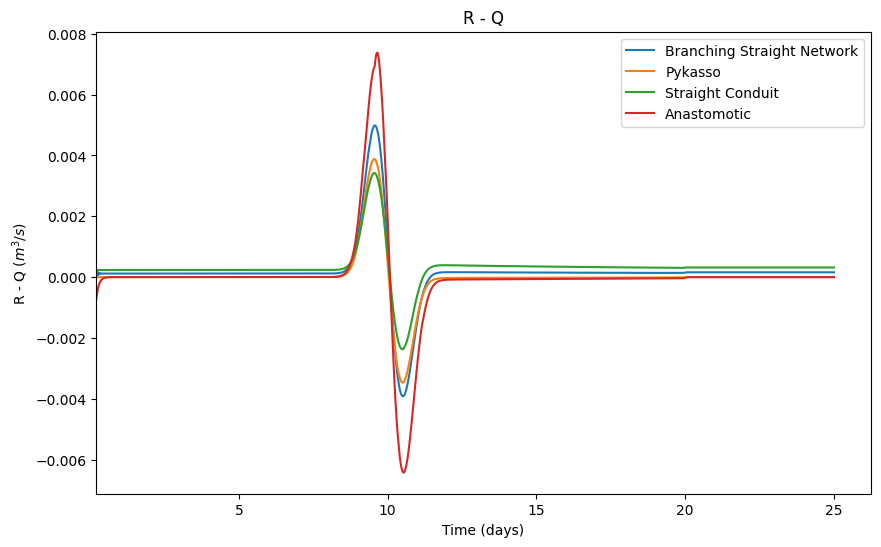

In [115]:
fig, ax = plt.subplots(figsize=(10,6))
residual_df = pd.DataFrame(columns=['network_name', 'positive_peak_time', 'positive_peak_value',  'negative_peak_time', 'negative_peak_value', 'pulse_width'])
for name, Q_spring in all_Q.items():
    if conditions(name):
        continue
    r_interp = np.interp(Q_spring['time'], r['time'], r['R_l [V/T]'] + r['R_h [V/T]'])
    residual = (r_interp - Q_spring['Q'])[100: ] #ignore initial noise
    t_residual = Q_spring['time'][100: ]
    threshold = 0.1 * np.max(np.abs(residual))
    mask = np.abs(residual) > threshold
    width = t_residual[mask].values[-1] - t_residual[mask].values[0]
    positive_peak_time = t_residual[mask].values[residual[mask].argmax()]
    positive_peak_value = residual[mask].max()
    negative_peak_time = t_residual[mask].values[residual[mask].argmin()]
    negative_peak_value = residual[mask].min()
    residual_df.loc[len(residual_df)] =[label_dict[name], positive_peak_time/86400, positive_peak_value, negative_peak_time/86400, negative_peak_value, width/86400]
    sns.lineplot(x=Q_spring['time']/86400, y=residual, label=label_dict[name])
plt.legend(loc = 'upper right')
plt.xlabel('Time (days)')
plt.ylabel(r'R - Q ($m^3/s$)')
plt.title("R - Q")
plt.xlim(.2, )

In [116]:
residual_df['peak to peak time'] = residual_df['negative_peak_time'] - residual_df['positive_peak_time']
residual_df['peak to peak value'] = residual_df['positive_peak_value'] - residual_df['negative_peak_value']

In [117]:
residual_df

,network_name,positive_peak_time,positive_peak_value,negative_peak_time,negative_peak_value,pulse_width,peak to peak time,peak to peak value
0,Branching Straight Network,9.569445,0.004987,10.500003,-0.003919,11.081019,0.930558,0.008906
1,Pykasso,9.553244,0.003883,10.500000,-0.003473,2.460651,0.946756,0.007356
2,Straight Conduit,9.548613,0.003421,10.500001,-0.002375,7.006946,0.951388,0.005796
3,Anastomotic,9.650466,0.007375,10.541668,-0.006430,11.221062,0.891202,0.013804


In [118]:
residual_df[['network_name', 'pulse_width', 'peak to peak time', 'peak to peak value']]

,network_name,pulse_width,peak to peak time,peak to peak value
0,Branching Straight Network,11.081019,0.930558,0.008906
1,Pykasso,2.460651,0.946756,0.007356
2,Straight Conduit,7.006946,0.951388,0.005796
3,Anastomotic,11.221062,0.891202,0.013804


Text(0.5, 1.0, 'Recession Curves')

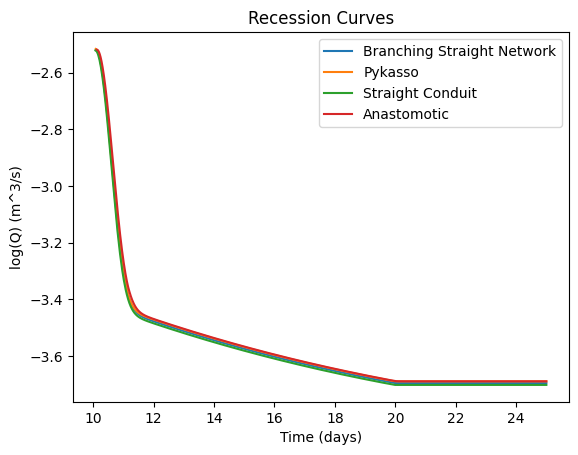

In [101]:
for name, spring_Q in all_Q.items():
    if conditions(name):
        continue
    peak_idx, peak_time, peak_flow = spring.find_peak(spring_Q['time'], spring_Q['Q'])
    logQ = np.log(spring_Q['Q'][peak_idx:])
    sns.lineplot(x=spring_Q['time'][peak_idx:]/86400, y=logQ, label=label_dict[name])
plt.xlabel('Time (days)')
plt.ylabel('log(Q) (m^3/s)')
plt.title("Recession Curves")

Text(0.5, 1.0, 'Effect of Cleaning Outlet')

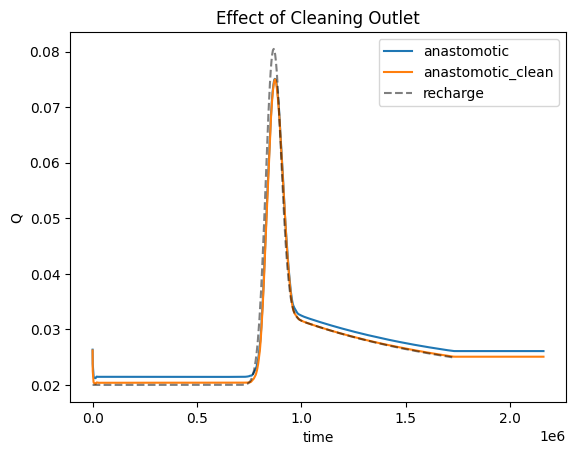

In [229]:
sns.lineplot(all_Q['anastomotic_simple'], x = 'time', y = all_Q['anastomotic_simple']['Q']-.01, label = 'anastomotic')
sns.lineplot(all_Q['anastomotic_simple_clean'], x = 'time', y = all_Q['anastomotic_simple_clean']['Q'] -.01, label = 'anastomotic_clean')
sns.lineplot(x=r['time'], y=r['R_l [V/T]'] + r['R_h [V/T]'], label='recharge', color='k', linestyle='--', alpha = 0.5)
plt.title("Effect of Cleaning Outlet")